In [11]:
# Loaded variable 'df' from URI: c:\Users\anura\AppData\Local\Temp\c58e43f9-35ec-4ad2-8e56-db21bf331cf0_archive (7).zip.cf0\matches.csv
import pandas as pd
df = pd.read_csv(r'c:\Users\anura\AppData\Local\Temp\c58e43f9-35ec-4ad2-8e56-db21bf331cf0_archive (7).zip.cf0\matches.csv')

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Handle Team Name Changes (Brutally necessary for IPL data)
# Example: Mapping old names to new ones so the model doesn't treat them as different teams
name_changes = {
    'Kings XI Punjab': 'Punjab Kings',
    'Delhi Daredevils': 'Delhi Capitals',
    'Rising Pune Supergiant': 'Rising Pune Supergiants'
}
df['team1'] = df['team1'].replace(name_changes)
df['team2'] = df['team2'].replace(name_changes)
df['toss_winner'] = df['toss_winner'].replace(name_changes)
df['winner'] = df['winner'].replace(name_changes)

# 2. Select Features & Drop Rows with missing winners (No Results/Tie)
# We use 'toss_decision' and 'venue' as they are key predictors found in EDA
features = df[['team1', 'team2', 'venue', 'toss_winner', 'toss_decision']].copy()
target = df['winner']

# Drop rows where there is no winner (matches called off)
valid_indices = target.dropna().index
features = features.loc[valid_indices]
target = target.loc[valid_indices]

# 3. One-Hot Encoding (Converts text to 0s and 1s)
X = pd.get_dummies(features, drop_first=True)
y = target

In [13]:
# Split data: 80% to train the "brain", 20% to test it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train
model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)
model.fit(X_train, y_train)

# Make Predictions
y_pred = model.predict(X_test)

# Results
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")


Model Accuracy: 56.69%


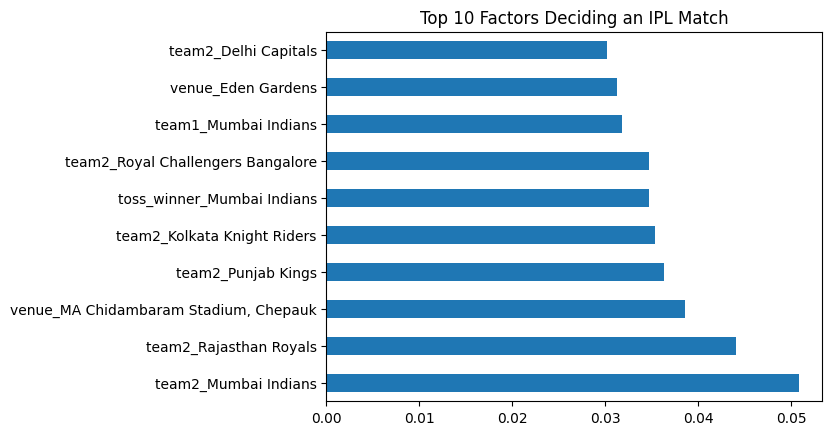

In [14]:
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Factors Deciding an IPL Match")
plt.show()